STEP 1: Import Required Libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import ssl

STEP 2: Load Grayscale Image

In [2]:
image_url = "https://drive.google.com/uc?export=download&id=11F2jKq_cUMbNo9-hEDr6WRag7kT7M3oN"

# Read and decode the image from URL
context = ssl._create_unverified_context()
resp = urllib.request.urlopen(image_url, context=context)
image_array = np.asarray(bytearray(resp.read()), dtype=np.uint8)
gray = cv2.imdecode(image_array, cv2.IMREAD_GRAYSCALE)

if gray is None:
    raise Exception("❌ Image could not be loaded.")
else:
    print("✅ Image successfully loaded.")

✅ Image successfully loaded.


STEP 3: Binary Thresholding for Segmentation

    ➤ Convert grayscale to binary image using Otsu’s method
    ➤ Otsu finds optimal threshold by minimizing intra-class variance

    # Binary image has:
      - Foreground (object): 255
      - Background: 0

In [3]:
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

STEP 4: Connected Component Labeling (8-connectivity)

    ➤ Importance:
      # Connected Component Labeling (CCL) assigns a unique label to each
      # connected region of white pixels in the binary image.
      # Useful in object counting, segmentation, and shape analysis.

    ➤ Algorithm:
        - For each foreground pixel, check 8 neighbors.
        - Group connected pixels under the same label.
        - Output: a label matrix where each region has a unique integer.

    ➤ Formula Conceptually:
       If pixel(x, y) == 255:
           Assign label L(x, y) based on connected neighbors
           Merge labels if multiple neighbors are labeled

In [4]:
# Apply OpenCV function:
num_labels, labels = cv2.connectedComponents(binary, connectivity=8)

print(f"🔎 Total Connected Components (including background): {num_labels}")

🔎 Total Connected Components (including background): 122


STEP 5: Color Mapping for Visualization

    ➤ Create a color output where each component gets a unique color

In [5]:
# Normalize label values to 0–255 range for display
label_hue = np.uint8(179 * labels / np.max(labels))
blank_ch = 255 * np.ones_like(label_hue)

# Merge hue channel with saturation/value to create HSV image
colored_labels = cv2.merge([label_hue, blank_ch, blank_ch])
colored_labels = cv2.cvtColor(colored_labels, cv2.COLOR_HSV2BGR)

# Set background label to black
colored_labels[label_hue == 0] = 0


STEP 6: Display Results

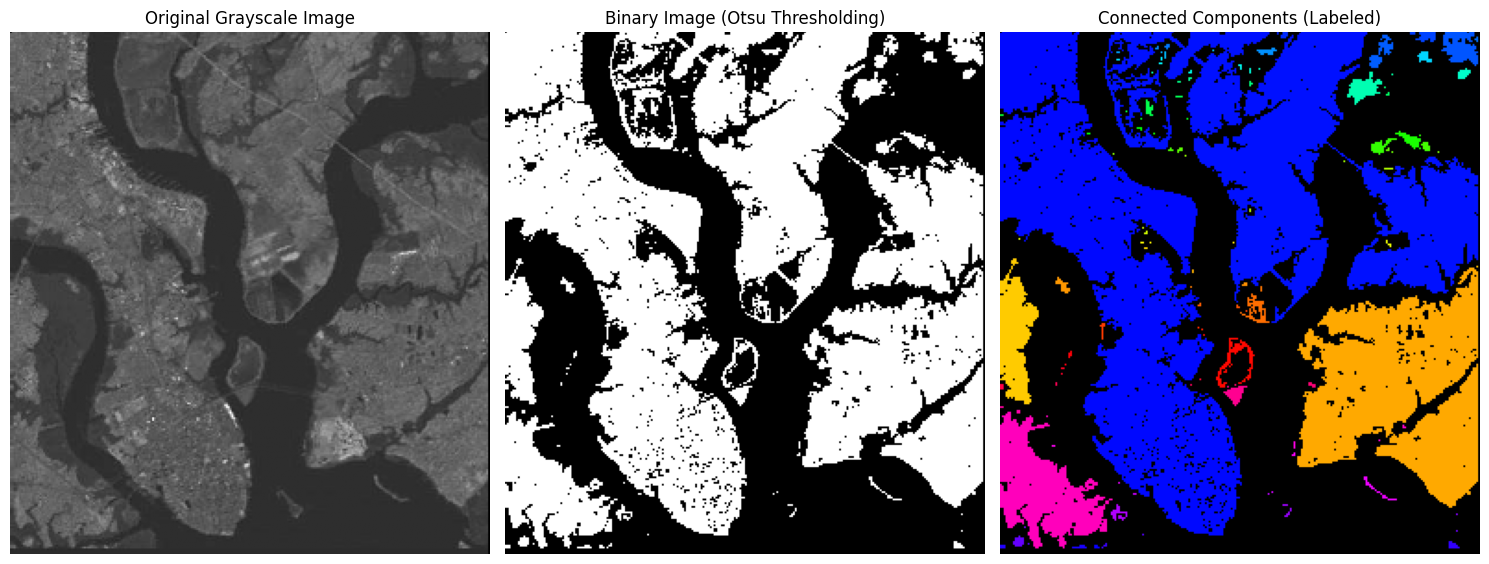

In [6]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(binary, cmap='gray')
plt.title("Binary Image (Otsu Thresholding)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(colored_labels)
plt.title("Connected Components (Labeled)")
plt.axis('off')

plt.tight_layout()
plt.show()